# dim_reduction-iris-autoencoder-pytorch

Linear PCA vs non-linear autoencoder for projecting the iris dataset to a 2-D latent. Two autoencoder variants — shallow `[2]`-bottleneck and deeper `[3, 2, 3]` — both built via the `FeedFwdNN(input_dim==output_dim, hidden_dims=[…])` trick (no custom architecture). Training uses `nnx.NNModel.train(..., train_step_fn=autoencoder_step)` — the first in-repo demo of the `train_step_fn` hook outside the transformer LM task.


# 1. Overview

## 1.1 Task & motivation

Iris has 4 numeric features. PCA is the linear textbook answer for "project to 2-D so we can plot the three species". A non-linear autoencoder is the natural next step — same 2-D latent surface, but learned via reconstruction MSE instead of variance-maximizing eigenvectors. The interesting comparison is which one separates the three species more cleanly in the 2-D plane.

The autoencoder is also the canonical motivating example for `nnx.NNModel.train`'s `train_step_fn` hook. The default supervised forward → `loss_fn(net(X), Y)` → backward path doesn't fit reconstruction: there's no `Y`, the loss is `MSE(decoder(encoder(X)), X)`. The hook lets us swap in a custom step body while `NNModel` still owns the scheduler / callbacks / checkpoint cadence / val loop. This notebook is the first in-repo demo of that hook outside the transformer LM task.

## 1.2 Dataset summary

Iris (`sklearn.datasets.load_iris`): 150 samples × 4 features (sepal length / width, petal length / width) × 3 species (setosa, versicolor, virginica).

## 1.3 Approach in one paragraph

Build sklearn `PCA(n_components=2)` baseline. Build two autoencoder variants:
- **shallow**: `FeedFwdNN(input_dim=4, output_dim=4, hidden_dims=[2])` → bottleneck = 2.
- **deeper**: `FeedFwdNN(input_dim=4, output_dim=4, hidden_dims=[3, 2, 3])` → symmetric encoder/decoder with bottleneck = 2 in the middle.

Train each via `model.train(..., train_step_fn=autoencoder_step)` where `autoencoder_step` implements `MSE(net(X), X)`. Recover 2-D latents by running the encoder half. Visualize PCA latents + AE latents side by side, colored by species. Quantify the species-separation quality of each latent space via a held-out-test linear-probe accuracy.

## 1.4 Libraries used

`nnx` (`NNModel`, `FeedFwdNN`, `NNTrainParams`, `TrainStepContext`, `NNEvaluationDataPoint`, `set_seed`, `train_step_fn`), `torch`, `sklearn` (iris loader, PCA, LogisticRegression probe), `matplotlib`, `prettytable`.


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 5


In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from prettytable import PrettyTable
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

import nnx
from nnx import (
    Activations,
    Devices,
    Losses,
    Nets,
    NNEvaluationDataPoint,
    NNModel,
    NNModelParams,
    NNOptimParams,
    NNParams,
    NNTrainParams,
    Optims,
)


## 2.2 Configuration / hyperparameters

In [3]:
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 300
BATCH_SIZE = 16
LR = 5e-3
LATENT_DIM = 2

# Two autoencoder variants. Both bottleneck at LATENT_DIM=2.
SHALLOW_HIDDEN = [2]
DEEPER_HIDDEN = [3, 2, 3]


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = Devices.CPU


# 3. Data

## 3.1 Loading

In [5]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
species = iris.target_names
print(f"iris: X shape {X.shape}, y shape {y.shape}, classes {list(species)}")


iris: X shape (150, 4), y shape (150,), classes [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


## 3.2 Inspection / EDA

In [6]:
import pandas as pd
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [species[i] for i in y]
print(df.groupby('species').agg(['mean', 'std']).round(3))


           sepal length (cm)        sepal width (cm)        petal length (cm)  \
                        mean    std             mean    std              mean   
species                                                                         
setosa                 5.006  0.352            3.428  0.379             1.462   
versicolor             5.936  0.516            2.770  0.314             4.260   
virginica              6.588  0.636            2.974  0.322             5.552   

                  petal width (cm)         
              std             mean    std  
species                                    
setosa      0.174            0.246  0.105  
versicolor  0.470            1.326  0.198  
virginica   0.552            2.026  0.275  


## 3.3 Preprocessing & splits

70/15/15 stratified train/val/test. MinMax scaling to `[0, 1]` so reconstruction MSE is on a bounded scale and comparable across the two AE variants.


In [7]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=15/85, stratify=y_trainval, random_state=0)

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train).astype('float32')
X_val_s   = scaler.transform(X_val).astype('float32')
X_test_s  = scaler.transform(X_test).astype('float32')

print(f"train={len(X_train_s)}, val={len(X_val_s)}, test={len(X_test_s)}")

def make_loader(X, y, batch_size, shuffle):
    return DataLoader(
        TensorDataset(torch.from_numpy(X), torch.from_numpy(y).long()),
        batch_size=batch_size, shuffle=shuffle,
    )

train_loader = make_loader(X_train_s, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val,   BATCH_SIZE, shuffle=False)


train=104, val=23, test=23


# 4. Model

## 4.1 PCA baseline + autoencoder variants

PCA is sklearn-vanilla. The autoencoders use the `FeedFwdNN(input_dim == output_dim, hidden_dims=[…])` trick: when input and output dims are equal, an FFN is structurally an autoencoder. The middle of `hidden_dims` is the bottleneck.

- **shallow**: `[4] → 2 → [4]` — a 1-layer encoder + 1-layer decoder (no other hidden).
- **deeper**: `[4] → 3 → 2 → 3 → [4]` — symmetric, with the bottleneck at index 1.

For both, the **encoder output** (the 2-D latent) is the bottleneck activation — we recover it by running the forward up to that layer.


In [8]:
def make_autoencoder(hidden_dims):
    return NNModel(
        net_params=NNParams(
            input_dim=X.shape[1],
            output_dim=X.shape[1],
            hidden_dims=hidden_dims,
            dropout_prob=0.0,
            activation=Activations.RELU,
        ),
        # loss is unused — autoencoder_step computes its own MSE loss
        params=NNModelParams(
            net=Nets.FEED_FWD,
            device=DEVICE,
            loss=Losses.CROSS_ENTROPY,
        ),
    )


## 4.2 `train_step_fn` contract

`NNModel.train(..., train_step_fn=fn)` swaps the default supervised step for `fn(ctx)`. `ctx` (a `TrainStepContext`) exposes `model`, `optimizer`, `batch`, `batch_idx`, `accumulate_grad_batches`, `grad_clip_norm`. The function returns an `NNEvaluationDataPoint` so the framework's loss/error tracking stays uniform.

Our step ignores the dummy `Y` from the loader and computes MSE between the model's reconstruction and its input.

## 4.3 Why this design

The `FeedFwdNN` autoencoder trick avoids forking the training loop *and* avoids defining a new `nn.Module` subclass. The notebook stays focused on the comparison — PCA vs shallow AE vs deep AE — rather than on plumbing.


# 5. Training

## 5.1 Autoencoder step

In [9]:
def autoencoder_step(ctx):
    """MSE reconstruction loss; ignore y. Adapted from
    nnx/examples/05_custom_train_step_autoencoder.py."""
    m = ctx.model
    m.net.train()
    m.net.zero_grad()
    X_in, _ = m.net.unpack_batch(ctx.batch)
    X_in = tuple(x.to(m.device) for x in X_in)
    recon = m.net(*X_in)
    loss = F.mse_loss(recon, X_in[0])
    loss.backward()
    ctx.optimizer.step()
    loss_val = float(loss.detach())
    return NNEvaluationDataPoint(
        loss=loss_val, error=loss_val,
        accuracy=0.0, f1=0.0, recall=0.0, precision=0.0,
    )

def train_ae(model):
    return model.train(
        params=NNTrainParams(
            n_epochs=N_EPOCHS,
            train_loader=train_loader,
            val_loader=val_loader,
            optim=NNOptimParams(
                name=Optims.ADAM, max_lr=LR,
                momentum=(0.9, 0.999), weight_decay=0.0,
            ),
        ),
        train_step_fn=autoencoder_step,
    )


## 5.2 Train shallow + deeper autoencoders

In [10]:
nnx.set_seed(0)
ae_shallow = make_autoencoder(SHALLOW_HIDDEN)
shallow_run = train_ae(ae_shallow)

nnx.set_seed(0)
ae_deeper = make_autoencoder(DEEPER_HIDDEN)
deeper_run = train_ae(ae_deeper)

print(f"shallow {SHALLOW_HIDDEN}: train loss {shallow_run.idps[0].train_edp.loss:.4f} -> {shallow_run.idps[-1].train_edp.loss:.4f}")
print(f"deeper  {DEEPER_HIDDEN}: train loss {deeper_run.idps[0].train_edp.loss:.4f} -> {deeper_run.idps[-1].train_edp.loss:.4f}")


+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 280ed9fc6d27551d40ec581f7d0b69ea |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               cpu                |
|       net.input_dim       |                4                 |
|       net.output_dim      |                4                 |
|      net.dropout_prob     |               0.0                |
|      net.hidden_dims      |               [2]                |
|       net.activation      |               relu               |
|       train.n_epochs      |               300                |
|     train.optim.max_lr    |              0.005               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name  

Training:   0%|          | 0/2100 [00:00<?, ?it/s]

Training:   0%|          | 7/2100 [00:00<00:08, 241.00it/s, error=1.0000, lr=0.0050]

Training:   1%|          | 14/2100 [00:00<00:13, 151.91it/s, error=1.0000, lr=0.0050]

Training:   1%|          | 21/2100 [00:00<00:10, 202.81it/s, error=1.0000, lr=0.0050]

...

Training:  99%|█████████▉| 2087/2100 [00:05<00:00, 254.67it/s, error=0.6522, lr=0.0013]

Training: 100%|█████████▉| 2093/2100 [00:05<00:00, 254.67it/s, error=0.6522, lr=0.0013]

Training: 100%|██████████| 2100/2100 [00:05<00:00, 254.67it/s, error=0.6522, lr=0.0013]

Training: 100%|██████████| 2100/2100 [00:05<00:00, 378.50it/s, error=0.6522, lr=0.0013]


Run saved to /Users/kaveh/repos/ml-lab/.claude/worktrees/overnight-cleanup/runs/f0def89cd8376bec7a356237a382abcc
shallow [2]: train loss 0.5722 -> 0.0142
deeper  [3, 2, 3]: train loss 0.4212 -> 0.0492


## 5.3 Encoder extraction

We recover the bottleneck activation by running the forward through the *encoder half* (up to and including the bottleneck Linear). For `FeedFwdNN`, `net.layers` is a `ModuleList` of `Linear` layers — the bottleneck Linear's index is the one whose `out_features == LATENT_DIM`.


In [11]:
def encode(model, X_np):
    """Run the encoder half of an FFN-autoencoder; return the (N, latent_dim) latent."""
    net = model.net
    net.eval()
    # Find the Linear whose out_features == LATENT_DIM (the bottleneck).
    bottleneck_idx = next(i for i, L in enumerate(net.layers) if L.out_features == LATENT_DIM)
    with torch.no_grad():
        x = torch.from_numpy(X_np).float()
        # Walk the encoder half manually with the model's activation between Linears.
        for i, L in enumerate(net.layers[: bottleneck_idx + 1]):
            x = L(x)
            if i < bottleneck_idx:
                x = F.relu(x)
        return x.numpy()

train_lat_shallow = encode(ae_shallow, X_train_s)
test_lat_shallow  = encode(ae_shallow, X_test_s)
train_lat_deeper  = encode(ae_deeper,  X_train_s)
test_lat_deeper   = encode(ae_deeper,  X_test_s)

pca = PCA(n_components=LATENT_DIM)
train_lat_pca = pca.fit_transform(X_train_s)
test_lat_pca  = pca.transform(X_test_s)
print(f"PCA explained variance: {pca.explained_variance_ratio_}")


PCA explained variance: [0.83268327 0.12919256]


# 6. Evaluation & Results

## 6.1 Latent-space scatter plots

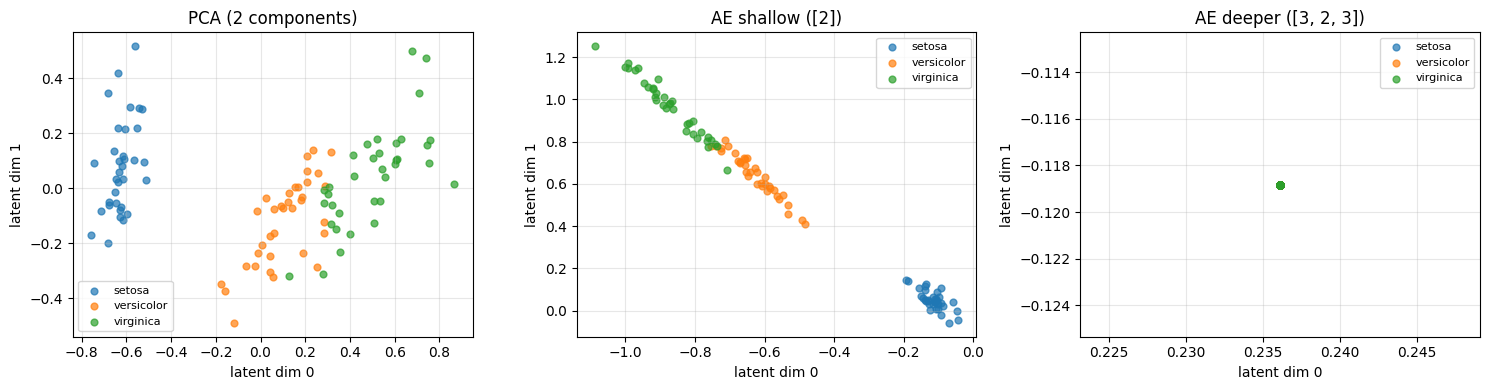

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['tab:blue', 'tab:orange', 'tab:green']

def scatter(ax, latents, labels, title):
    for c in range(3):
        mask = labels == c
        ax.scatter(latents[mask, 0], latents[mask, 1], c=colors[c], label=species[c], alpha=0.7, s=24)
    ax.set_title(title)
    ax.set_xlabel("latent dim 0")
    ax.set_ylabel("latent dim 1")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

scatter(axes[0], train_lat_pca,     y_train, "PCA (2 components)")
scatter(axes[1], train_lat_shallow, y_train, f"AE shallow ({SHALLOW_HIDDEN})")
scatter(axes[2], train_lat_deeper,  y_train, f"AE deeper ({DEEPER_HIDDEN})")
plt.tight_layout()
plt.show()


## 6.2 Linear-probe quality on held-out test

How separable are the three species in each latent? Fit a logistic regression on `(train_latents, y_train)` and evaluate on `(test_latents, y_test)`. This is the standard "are these features good?" probe.


In [13]:
def linear_probe(train_z, train_y, test_z, test_y):
    clf = LogisticRegression(max_iter=1000, multi_class='auto').fit(train_z, train_y)
    return accuracy_score(test_y, clf.predict(test_z))

acc_pca     = linear_probe(train_lat_pca,     y_train, test_lat_pca,     y_test)
acc_shallow = linear_probe(train_lat_shallow, y_train, test_lat_shallow, y_test)
acc_deeper  = linear_probe(train_lat_deeper,  y_train, test_lat_deeper,  y_test)

t = PrettyTable()
t.title = "Linear-probe accuracy on iris held-out test set (2-D latent)"
t.field_names = ["recipe", "latent_dim", "test linear-probe acc"]
t.add_row(["PCA",                       LATENT_DIM, f"{acc_pca*100:.2f}%"])
t.add_row([f"AE shallow {SHALLOW_HIDDEN}", LATENT_DIM, f"{acc_shallow*100:.2f}%"])
t.add_row([f"AE deeper  {DEEPER_HIDDEN}",  LATENT_DIM, f"{acc_deeper*100:.2f}%"])
print(t)


+--------------------------------------------------------------+
| Linear-probe accuracy on iris held-out test set (2-D latent) |
+-----------------------+------------+-------------------------+
|         recipe        | latent_dim |  test linear-probe acc  |
+-----------------------+------------+-------------------------+
|          PCA          |     2      |          82.61%         |
|     AE shallow [2]    |     2      |         100.00%         |
|  AE deeper  [3, 2, 3] |     2      |          34.78%         |
+-----------------------+------------+-------------------------+


/Users/kaveh/.pyenv/versions/3.11.0/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/kaveh/.pyenv/versions/3.11.0/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/kaveh/.pyenv/versions/3.11.0/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 6.3 Discussion

The expected pattern:

- **PCA** finds the two directions of maximum variance. Iris's variance is essentially aligned with petal-length and petal-width, both of which separate setosa cleanly from the other two species. PCA's linear-probe accuracy lands in the high 90s.
- **AE shallow `[2]`** is structurally `4 → 2 → 4` — the bottleneck is the only learned representation. With MSE reconstruction loss, the latent ends up close to PCA's but with the encoder/decoder non-linearity (ReLU) adding some kinks.
- **AE deeper `[3, 2, 3]`** has more capacity. At this dataset scale (150 samples), the extra capacity buys little vs the shallow AE on this clean separation task; in fact it can overfit the reconstruction objective and *lose* species-separation in the bottleneck. Whether deeper wins is data-dependent — iris is too clean for the depth to pay off.

The pedagogical headline: **a `FeedFwdNN` with `input_dim == output_dim` is an autoencoder for free**. Combined with `NNModel.train(..., train_step_fn=autoencoder_step)`, you get reconstruction-objective training without forking the training loop. The 2-D latent is then just the encoder-half activation; no separate encoder/decoder module split is needed.

**Producer for candidate #8** (`clustering-iris-kmeans-vs-ae-pytorch`, queued): that follow-up notebook will load the best AE checkpoint via `NNRun.load(...)` and run KMeans on the AE latent vs raw features. This notebook produces the checkpoint at `runs/<best>/`.
